<a href="https://colab.research.google.com/github/isamadafridi/potato_model/blob/main/potato_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [58]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.layers import Resizing, Rescaling, Conv2D, MaxPooling2D, Flatten,GlobalAveragePooling2D , Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import matplotlib.pyplot as plt
import numpy as np

In [59]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Data Loading**

In [60]:
# import kagglehub
# import shutil
# import os

# # Step 1: Download dataset (default location)
# path = kagglehub.dataset_download("arjuntejaswi/plant-village")

# # Step 2: Define your desired path
# target_path = '/content/drive/MyDrive/Datasets'

# # Step 3: Move dataset
# shutil.move(path, target_path)

# print("Dataset moved to:", target_path)

In [78]:
DATASET_PATH = '/content/drive/MyDrive/datasets/plant_village/PlantVillage'

In [79]:
from PIL import Image
img_path = '/content/drive/MyDrive/datasets/plant_village/PlantVillage/Potato___Late_blight/0051e5e8-d1c4-4a84-bf3a-a426cdad6285___RS_LB 4640.JPG'
img = Image.open(img_path)
print(img.size)   # (width, height)

(256, 256)


In [80]:
# STEP 1: Load Dataset
dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    class_names=[
        "Potato___Early_blight",
        "Potato___Late_blight",
        "Potato___healthy"
    ],
    shuffle = True,
    image_size=(256, 256),
    batch_size=32
)

Found 2152 files belonging to 3 classes.


In [81]:
CLASS_NAMES = dataset.class_names
CLASS_NAMES

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [82]:
print(f"Size without batch : {len(dataset)}")
print(f"Size with batch : {len(dataset)*32}")

Size without batch : 68
Size with batch : 2176


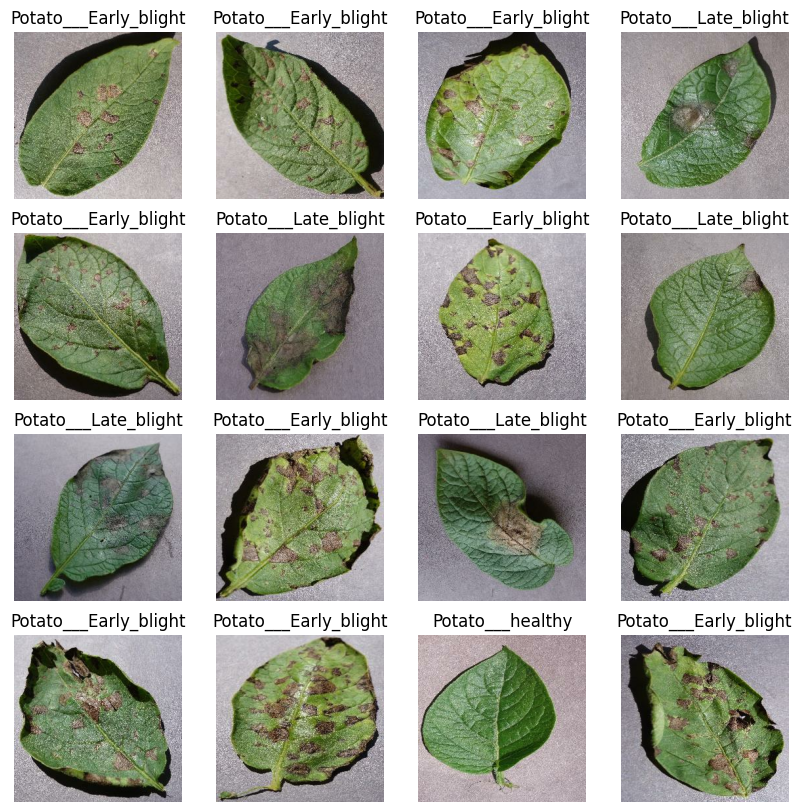

In [83]:
plt.figure(figsize=(10,10))
for image, label in dataset.take(1):
  for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(image[i].numpy().astype('uint8'))
    plt.title(dataset.class_names[label[i].numpy()])
    plt.axis('off')

In [84]:
#  STEP 2: Split Dataset
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):

  ds_size = len(ds)
  if shuffle:
    ds = ds.shuffle(shuffle_size, seed=12)

  train_size = int(train_split * ds_size)
  val_size = int(val_split * ds_size)

  train_ds = ds.take(train_size)
  val_ds = ds.skip(train_size).take(val_size)
  test_ds = ds.skip(train_size).skip(val_size)


  return train_ds, val_ds, test_ds

train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [85]:
print(len(train_ds)*32)
print(len(val_ds)*32)
print(len(test_ds)*32)

1728
192
256


In [86]:
# Class Distribution
class_counts = [0, 0, 0]
for images, labels in dataset:
    for label in labels.numpy():
        class_counts[label] += 1

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]
for name, count in zip(CLASS_NAMES, class_counts):
    print(f"{name}: {count} images")

Early Blight: 1000 images
Late Blight: 1000 images
Healthy: 152 images


In [87]:
# STEP 5: Performance Optimization before maping, if dataset <5GB
# ============================================================
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds   = val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# **Data pre-processing**

In [29]:
# resize_rescale_layers = tf.keras.Sequential([
#     Resizing(256, 256),
#     Rescaling(1./255)
# ])
# it cover procesiing unit

In [88]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),     # ✅ keep — realistic for leaves
    layers.RandomRotation(0.15),         # ✅ keep — camera angle variation
    layers.RandomZoom(0.1),              # ✅ keep — camera distance

    layers.RandomBrightness(0.1),        # ⚠️  optional — keep if outdoor images

    # layers.RandomFlip("vertical"),       # ❌ remove — unnatural leaf position
    # layers.RandomContrast(0.2),          # ❌ remove — hides disease spots
    # layers.RandomTranslation(0.1, 0.1), # ❌ remove — not needed

])

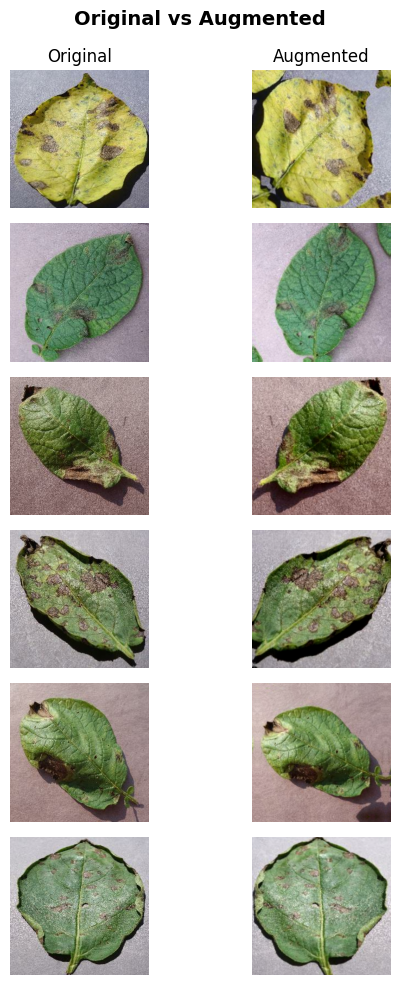

In [89]:
# 1. Get a batch
for images, labels in train_ds.take(1):
    raw_images = images
    break

fig, axes = plt.subplots(6, 2, figsize=(6, 10))
fig.suptitle("Original vs Augmented", fontsize=14, fontweight='bold')

for i in range(6):
    # Keep the batch dimension (1, H, W, C)
    original = raw_images[i:i+1]

    # Apply augmentation
    augmented = data_augmentation(original, training=True)

    # --- THE FIX: Safe Normalization for Plotting ---
    # Convert tensors to numpy arrays and remove the batch dimension
    orig_np = np.squeeze(original.numpy())
    aug_np = np.squeeze(augmented.numpy())

      # Normalize the arrays to be strictly between 0.0 and 1.0 for matplotlib
      # We do this by subtracting the minimum value and dividing by the range
    orig_display = (orig_np - np.min(orig_np)) / (np.max(orig_np) - np.min(orig_np) + 1e-5)
    aug_display = (aug_np - np.min(aug_np)) / (np.max(aug_np) - np.min(aug_np) + 1e-5)

    # Plot Original (Left)
    axes[i, 0].imshow(orig_display, cmap='gray')
    axes[i, 0].set_title("Original" if i == 0 else "")
    axes[i, 0].axis('off')

    # Plot Augmented (Right)
    axes[i, 1].imshow(aug_display, cmap='gray')
    axes[i, 1].set_title("Augmented" if i == 0 else "")
    axes[i, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Give the title some breathing room
plt.show()

In [68]:
#  STEP 4: Apply Preprocessing
# TRAIN — preprocess + augment
train_ds = train_ds.map(
    lambda x, y: (data_augmentation(preprocess_input(x), training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE   # 🔥 runs in parallel on CPU
)

# VAL — only preprocess
val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

# TEST — only preprocess
test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

In [90]:
# TRAIN
train_ds = train_ds.cache()          # 1. cache raw images
train_ds = train_ds.map(
    lambda x, y: (preprocess_input(data_augmentation(x, training=True)), y),
    num_parallel_calls=tf.data.AUTOTUNE   # 2. augment → preprocess ✅
)
train_ds = train_ds.shuffle(1000).prefetch(tf.data.AUTOTUNE)  # 3. shuffle → prefetch

# VAL
val_ds = val_ds.cache()
val_ds = val_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# TEST
test_ds = test_ds.cache()
test_ds = test_ds.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=tf.data.AUTOTUNE
)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# **Model Selection**

# Pretrained Model

In [91]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(256, 256, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False   # ✅ fully frozen

model = tf.keras.Sequential([
    Input(shape=(256, 256, 3)),

    base_model,

    GlobalAveragePooling2D(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(3, activation='softmax')
])
model.summary()

/tmp/ipykernel_1492/1884842147.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# **Model Saving**

In [92]:
import os
import re

base_path = '/content/drive/MyDrive/best_model'
model_name = "potato_model_mobileNetV2"

files = os.listdir(base_path)

versions = []

for f in files:
    if f.startswith(model_name) and f.endswith(".keras"):
        match = re.search(r'_v(\d+)', f)
        if match:
            versions.append(int(match.group(1)))

# next version
i = max(versions) + 1 if versions else 0

filepath = f"{base_path}/{model_name}_v{i}.keras"

print(filepath)

/content/drive/MyDrive/best_model/potato_model_mobileNetV2_v1.keras


# **Model Compailation**

In [93]:
callback = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,                  # ✅ increased from 3
        mode='max',
        restore_best_weights=True    # ✅ restores best epoch weights
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.3,
        patience=3,                  # ✅ runs BEFORE EarlyStopping
        mode='max',
        min_lr=1e-6                  # ✅ don't go below this
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath,
        monitor='val_accuracy',
        save_best_only=True,         # ✅ only saves best epoch
        mode='max'
    )
]

In [94]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),  # ✅ lower LR for pretrained
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),  # ✅ correct
    metrics=['accuracy']
)

In [95]:
# Tell model to pay more attention to Healthy class
class_weights = {
    0: 1.0,   # Early Blight
    1: 1.0,   # Late Blight
    2: 6.5    # Healthy ← 1000/152 = 6.5x more attention
}

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=callback,
    class_weight=class_weights   # ✅ add this
)

Epoch 1/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 49s 321ms/step - accuracy: 0.8565 - loss: 0.5052 - val_accuracy: 0.9323 - val_loss: 0.1782 - learning_rate: 0.0010
Epoch 2/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9543 - loss: 0.1999 - val_accuracy: 0.9167 - val_loss: 0.1621 - learning_rate: 0.0010
Epoch 3/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 55ms/step - accuracy: 0.9566 - loss: 0.1531 - val_accuracy: 0.9688 - val_loss: 0.0695 - learning_rate: 0.0010
Epoch 4/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 43ms/step - accuracy: 0.9757 - loss: 0.1192 - val_accuracy: 0.9531 - val_loss: 0.0823 - learning_rate: 0.0010
Epoch 5/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - accuracy: 0.9722 - loss: 0.1111 - val_accuracy: 0.9740 - val_loss: 0.0629 - learning_rate: 0.0010
Epoch 6/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.9792 - loss: 0.0719 - val_accuracy: 1.0000 - val_loss: 0.0271 - learning_rate: 0.0010
Epoch 7/50
54/54 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.9780 - loss: 0.0844 -

# Plot training & validation accuracy & losses values

In [44]:
# import tensorflow as tf
# model_path = '/content/best_potato_model.keras'
# model1 = tf.keras.models.load_model(model_path)
# print("Model loaded ✅")

Model loaded ✅


Epoch 01 → Train: 85.65%  Val: 93.23%  | Train Loss: 0.5052  Val Loss: 0.1782
Epoch 02 → Train: 95.43%  Val: 91.67%  | Train Loss: 0.1999  Val Loss: 0.1621
Epoch 03 → Train: 95.66%  Val: 96.88%  | Train Loss: 0.1531  Val Loss: 0.0695
Epoch 04 → Train: 97.57%  Val: 95.31%  | Train Loss: 0.1192  Val Loss: 0.0823
Epoch 05 → Train: 97.22%  Val: 97.40%  | Train Loss: 0.1111  Val Loss: 0.0629
Epoch 06 → Train: 97.92%  Val: 100.00%  | Train Loss: 0.0719  Val Loss: 0.0271
Epoch 07 → Train: 97.80%  Val: 99.48%  | Train Loss: 0.0844  Val Loss: 0.0379
Epoch 08 → Train: 98.32%  Val: 100.00%  | Train Loss: 0.0664  Val Loss: 0.0271
Epoch 09 → Train: 98.32%  Val: 96.88%  | Train Loss: 0.0684  Val Loss: 0.0553
Epoch 10 → Train: 99.02%  Val: 99.48%  | Train Loss: 0.0498  Val Loss: 0.0277
Epoch 11 → Train: 98.73%  Val: 100.00%  | Train Loss: 0.0465  Val Loss: 0.0284


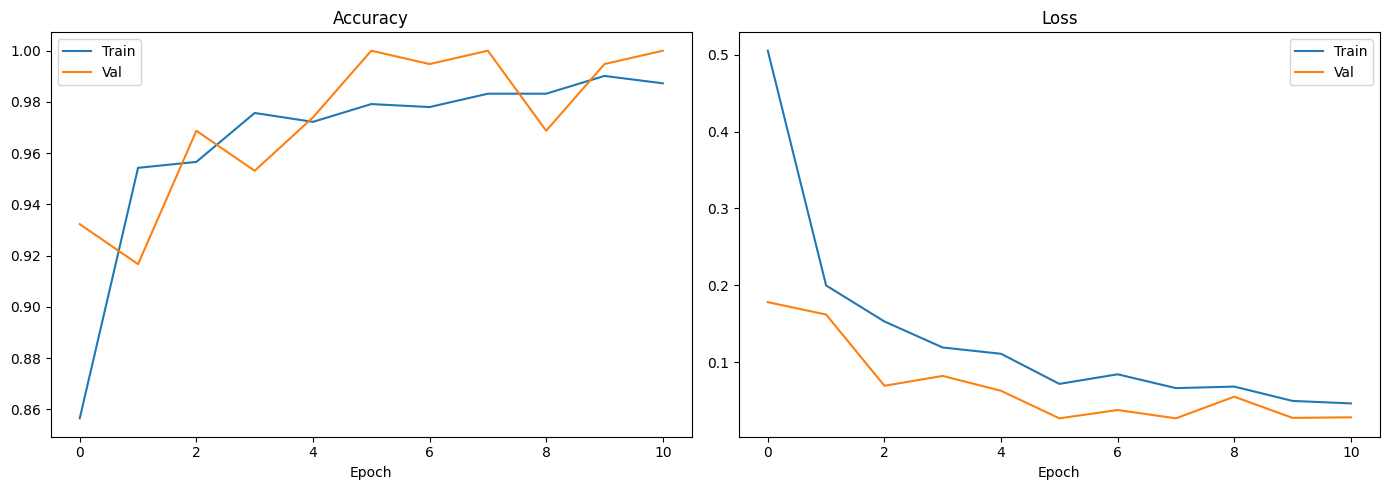

In [96]:
import matplotlib.pyplot as plt
for epoch, (acc, val_acc, loss, val_loss) in enumerate(zip(
    history.history['accuracy'],
    history.history['val_accuracy'],
    history.history['loss'],
    history.history['val_loss']
), 1):
    print(f"Epoch {epoch:02d} → Train: {acc*100:.2f}%  Val: {val_acc*100:.2f}%  | Train Loss: {loss:.4f}  Val Loss: {val_loss:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

# Loss
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()


# **Test on test dataset**

In [97]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 46ms/step - accuracy: 0.9844 - loss: 0.0446
Test Accuracy: 98.44%


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


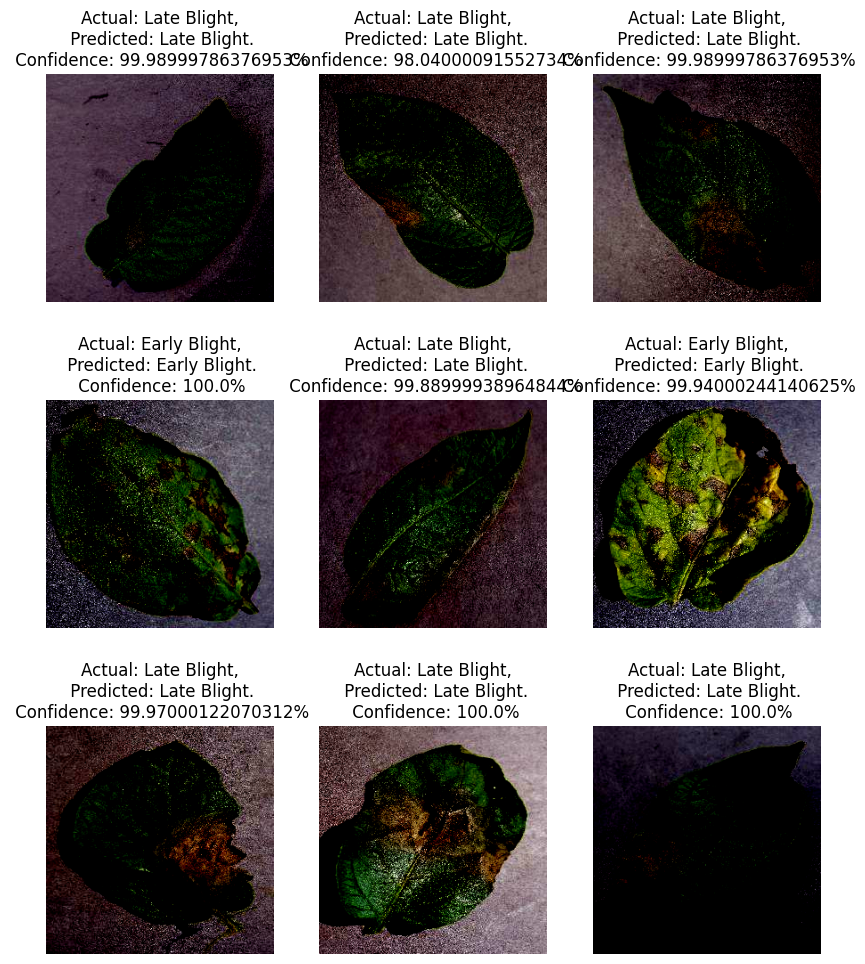

In [98]:
def predict(model, img):
    img_array = tf.expand_dims(img, 0) # Create a batch
    predictions = model.predict(img_array)

    predicted_class_index = np.argmax(predictions[0])
    predicted_class = CLASS_NAMES[predicted_class_index]
    confidence = round(100 * (np.max(predictions[0])), 2)
    return predicted_class, confidence

plt.figure(figsize=(10, 12))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())

        predicted_class, confidence = predict(model, images[i].numpy())
        actual_class = CLASS_NAMES[labels[i]] # Changed class_names to CLASS_NAMES

        plt.title(f"Actual: {actual_class},\n Predicted: {predicted_class}.\n Confidence: {confidence}%")

        plt.axis("off")

# Confusion Matrix

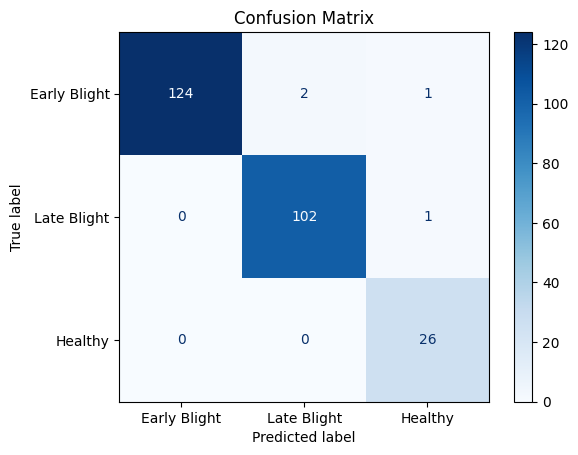

In [99]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

y_true, y_pred = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Early Blight", "Late Blight", "Healthy"]
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# **Testing**

In [110]:
from PIL import Image
import numpy as np
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

CLASS_NAMES = ["Early Blight", "Late Blight", "Healthy"]


path='/content/drive/MyDrive/datasets/plant_village/unseen_data/download (14).jpg'
img = Image.open(path).convert("RGB")
img = img.resize((256, 256))

img_array = np.array(img)
img_array = preprocess_input(img_array)
img_array = tf.expand_dims(img_array, 0)

predictions = model.predict(img_array)

print(f"Early Blight : {predictions[0][0]*100:.2f}%")
print(f"Late Blight  : {predictions[0][1]*100:.2f}%")
print(f"Healthy      : {predictions[0][2]*100:.2f}%")
print(f"Predicted    : {CLASS_NAMES[np.argmax(predictions[0])]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Early Blight : 5.49%
Late Blight  : 19.59%
Healthy      : 74.91%
Predicted    : Healthy


In [56]:
# Take one healthy image from dataset
for images, labels in dataset:
    for img, label in zip(images, labels):
        if label == 2:   # 2 = Healthy
            test_img = img
            break
    break

img_array = preprocess_input(test_img.numpy())
img_array = tf.expand_dims(img_array, 0)

pred = model.predict(img_array)
print(f"Early Blight : {pred[0][0]*100:.2f}%")
print(f"Late Blight  : {pred[0][1]*100:.2f}%")
print(f"Healthy      : {pred[0][2]*100:.2f}%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Early Blight : 0.05%
Late Blight  : 3.49%
Healthy      : 96.46%


# Download Zip file of model

In [52]:
import zipfile
import os
from google.colab import files

# Zip already saved model
with zipfile.ZipFile("potato_model.zip", "w") as zipf:
    zipf.write("/content/best_potato_model.keras")

# Download
files.download("potato_model.zip")
print("Downloading ✅")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>